<a href="https://colab.research.google.com/github/Deepaksoni-dot/Deepaksoni-dot/blob/DeepLearning/NeuralNetworkFromScratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####Objective:
 The primary objective is to predict the output value y based on two input features
 x1 and x2 using a basic neural network model with the equation y=3x1+4x2. The
 neural network will be trained using a feed-forward and back-propagation
 mechanism to minimize the error between the predicted and actual values.
####Methodology:
####1. Activation Functions:
 ● Define the sigmoid function, a popular activation function used in neural
 networks.
 ● Define the tanh function, which is another common activation function that
 returns values between-1 and 1.
 ● Define the relu function, which returns positive values as they are and
 zeroes out negative values.
####2. Sample Data:
 ● Usethe following sample data for training:
 x1=3, x2=2, yactual=17
####3. Feed Forward:
 ● Initialize the random weights w1 and w2 between 1 and 10.
 ● Predict the output ypred using the equation ypred= x1 x w1 + x2 x w2
####4. Error Calculation:
 ● Compute the squared error as error = (yactual-ypred)*(yactual-ypred)
####5. Back Propagation:
 ● Compute the gradients of the error with respect to the weights.
 ● Update the weights using the computed gradients and a learning rate.
####6. Training:
 ● Theabove steps (Feed Forward to Back Propagation) are performed
 iteratively (20 times in this example) to refine the weights and minimize
 the error.
####7. Visualization:
 ● Plot the progression of the error across epochs.
 ● Plot the progression of ypred across epochs

In [ ]:
import numpy as np

In [ ]:
# x1=3
# x2=2
# y=17  3x+4y
# w1=1
# w2=10
# eta=0.01

In [ ]:
x=np.array([[1,1],[3,2]])
y_act=np.array([7,17])

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))
def tanh(x):
  t1=np.exp(x)
  t2=np.exp(-x)
  return (t1-t2)/(t1+t2)
def relu(x):
  return np.maximum(0,x)

def propagation(w1,w2,eta,A):
  ls=[]
  for i in range(2):
    z1=w1*x[i][0]+w2*x[i][1]
    if A=="sigmoid":
      y_pred=sigmoid(z1)
      dy_pred=y_pred*(1-y_pred)
    elif A=="tanh":
      y_pred=tanh(z1)
      dy_pred=1-y_pred**2
    elif A=="relu":
      y_pred=relu(z1)
      dy_pred=1 if y_pred>0 else 0
    elif A=='none':
      y_pred=z1
      dy_pred=1

    del_C_del_w1=2*(y_pred-y_act[i])*dy_pred*x[i][0]
    del_C_del_w2=2*(y_pred-y_act[i])*dy_pred*x[i][1]
    ls.append(del_C_del_w1)
    ls.append(del_C_del_w2)
  w1=w1-eta*((ls[0]+ls[2])/2)  # somewhat like batch gradient
  w2=w2-eta*((ls[1]+ls[3])/2)
  return w1,w2,y_pred


In [ ]:
learning=0
w1=1
w2=10

ERROR=[]
Y_PRED=[]
while(learning<500):
  learning=learning+1
  w1,w2,Y_pred=propagation(w1,w2,eta=0.1,A='relu')
  Y_PRED.append(Y_pred)
  ERROR.append(np.abs(y_act[1]-Y_pred))
print(w1,w2)

2.8787570825135878 4.172044295279324


In [ ]:
print(w1*x[1][0]+w2*x[1][1])

16.98035983809941


since we have given only one sample (3,2) for y=3x+4y.
I have used another point (1,1) and applied batch gradient so that propagation function can converge to the solution ie weights w1,w1=3,4.

x1=3
x2=2
 y=17  3x+4y

x1,x2=1,1 y=7

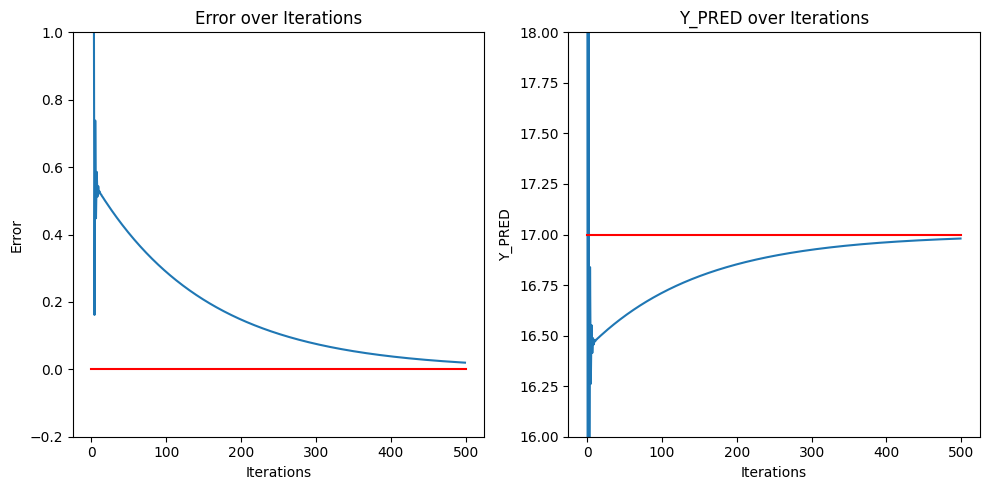

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(ERROR)
plt.title('Error over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Error')
plt.plot([0, 500], [0, 0], color='red')
plt.ylim(-0.2,1)

plt.subplot(122)
plt.plot(Y_PRED)
plt.title('Y_PRED over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Y_PRED')
plt.plot([0, 500], [17, 17], color='red')
plt.ylim(16, 18)
plt.tight_layout()
plt.show()


Over the iterations the y_pred is close to the actual value 17 for (3,2)